In [11]:
!pip install -U langchain langchain-groq langgraph python-dotenv langfuse pydantic google-api-python-client google-auth google-auth-oauthlib

Defaulting to user installation because normal site-packages is not writeable


In [12]:
import os
from typing import TypedDict, List, Dict, Any, Optional, Literal
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq  
from langchain_core.messages import HumanMessage
from pydantic import BaseModel, Field

In [13]:
# --- Gmail auth: reuse the OAuth client to build a Gmail API service ---
# Same credentials.json / token.json as before (scopes: gmail.readonly + gmail.compose),
# so no re-consent is needed. token.json auto-refreshes; the browser opens only once.
from google_auth_oauthlib.flow import InstalledAppFlow
from google.oauth2.credentials import Credentials
from google.auth.transport.requests import Request
from googleapiclient.discovery import build
from dotenv import load_dotenv

load_dotenv()  # GROQ_API_KEY, LANGFUSE_* from the repo-root .env

GMAIL_SCOPES = [
    "https://www.googleapis.com/auth/gmail.readonly",   # read & list messages
    "https://www.googleapis.com/auth/gmail.compose",    # create draft replies
]


def get_credentials(client_secrets="credentials.json", token_cache="token.json"):
    creds = None
    if os.path.exists(token_cache):
        creds = Credentials.from_authorized_user_file(token_cache, GMAIL_SCOPES)
    if not creds or not creds.valid:
        if creds and creds.expired and creds.refresh_token:
            creds.refresh(Request())                       # silent refresh
        else:
            flow = InstalledAppFlow.from_client_secrets_file(client_secrets, GMAIL_SCOPES)
            creds = flow.run_local_server(port=0)          # opens a browser once
        with open(token_cache, "w") as f:
            f.write(creds.to_json())
    return creds


gmail = build("gmail", "v1", credentials=get_credentials())
print("🔑 Gmail API ready for:", gmail.users().getProfile(userId="me").execute()["emailAddress"])

🔑 Gmail API ready for: sakibmansuri044@gmail.com


In [14]:
# --- Minimal Gmail helpers (direct Gmail REST API) ---
import base64
from email.mime.text import MIMEText


def list_unread(max_results=5):
    """Return [{id, threadId}, ...] for recent unread inbox mail."""
    res = gmail.users().messages().list(
        userId="me", q="is:unread -in:chats", maxResults=max_results
    ).execute()
    return res.get("messages", [])


def _decode(data: str) -> str:
    return base64.urlsafe_b64decode(data.encode()).decode("utf-8", errors="replace")


def _extract_body(payload: dict) -> str:
    """Depth-first search for the first text/plain body in a message payload."""
    if payload.get("mimeType") == "text/plain" and payload.get("body", {}).get("data"):
        return _decode(payload["body"]["data"])
    for part in payload.get("parts", []):
        text = _extract_body(part)
        if text:
            return text
    return ""


def get_email(msg_id: str) -> dict:
    """Fetch one message and flatten it to {id, thread_id, sender, subject, body}."""
    m = gmail.users().messages().get(userId="me", id=msg_id, format="full").execute()
    headers = {h["name"].lower(): h["value"] for h in m["payload"].get("headers", [])}
    return {
        "id": m["id"],
        "thread_id": m["threadId"],
        "sender": headers.get("from", ""),
        "subject": headers.get("subject", "(no subject)"),
        "body": _extract_body(m["payload"]) or m.get("snippet", ""),
    }


def create_draft_reply(to: str, subject: str, body: str, thread_id: str) -> dict:
    """Create a threaded draft reply in Gmail. Returns the created draft resource."""
    msg = MIMEText(body)
    msg["to"] = to
    msg["subject"] = subject
    raw = base64.urlsafe_b64encode(msg.as_bytes()).decode()
    return gmail.users().drafts().create(
        userId="me", body={"message": {"raw": raw, "threadId": thread_id}}
    ).execute()


langfuse_handler = None  # set later in the Langfuse cell (optional tracing)

### Step 1: setting up the State for Email


In [15]:
from typing import Annotated
from operator import add


class EmailState(TypedDict):
    # the raw email being processed (fetched from the Gmail MCP server)
    email: Dict[str, Any]

    # filled in by the LLM
    email_category: Optional[str]
    spam_reason: Optional[str]
    is_spam: Optional[bool]

    # the drafted reply for legitimate emails
    email_draft: Optional[str]

    # running log of what each node did (accumulated via the `add` reducer)
    messages: Annotated[List[Dict[str, Any]], add]

### defining LLM interface

In [16]:
# llm config (Groq serves open models — "gpt-4o" is not a Groq model)
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.2,
    max_tokens=1000,
    api_key=os.environ.get("GROQ_API_KEY"),
)

### defining the workflow functions / nodes

In [17]:
import re


# Structured output schema the LLM fills in when classifying an email.
# NOTE: Groq validates tool-call args strictly and llama models emit everything as
# strings — a `bool` field fails with "expected boolean, but got string". So we use a
# "yes"/"no" string enum and convert to bool ourselves.
class EmailClassification(BaseModel):
    spam: Literal["yes", "no"] = Field(
        description="'yes' if the email is spam / junk / phishing / mass promotion, else 'no'."
    )
    category: Literal["inquiry", "personal", "notification", "promotion", "spam", "other"] = Field(
        description="Best-fit category for the email."
    )
    reason: str = Field(description="Short justification for the classification.")


def _email_text(email: Dict[str, Any]) -> str:
    """Flatten an email dict into text the LLM can read."""
    return (
        f"From: {email.get('sender', 'unknown')}\n"
        f"Subject: {email.get('subject', '(no subject)')}\n\n"
        f"{email.get('body', '')}"
    )


def _plain_email(addr: Optional[str]) -> str:
    """Extract a bare address from a 'Name <email>' header value."""
    if not addr:
        return ""
    m = re.search(r"[\w.+-]+@[\w.-]+\.[\w.-]+", addr)
    return m.group(0) if m else addr


def read_email(state: EmailState) -> EmailState:
    """Read the email content and store it in the state."""
    email = state["email"]
    print(f"📥 Reading email from {email.get('sender')} — {email.get('subject')}")
    return {"messages": [{"role": "user", "content": _email_text(email)}]}


def categorize_email(state: EmailState) -> EmailState:
    """Categorize the email and flag spam using the LLM (structured output)."""
    classifier = llm.with_structured_output(EmailClassification)
    result: EmailClassification = classifier.invoke([
        HumanMessage(content=(
            "Classify the following email. Decide whether it is spam and pick its category.\n\n"
            + _email_text(state["email"])
        ))
    ])
    is_spam = result.spam == "yes"
    print(f"🏷️  category={result.category}  is_spam={is_spam}")
    return {
        "is_spam": is_spam,
        "email_category": "spam" if is_spam else result.category,
        "spam_reason": result.reason if is_spam else None,
    }


def report_spam_reason(state: EmailState) -> EmailState:
    """Spam path: just record the reason and stop (we don't mutate the mailbox)."""
    reason = state.get("spam_reason") or "Detected as spam."
    print(f"🚫 Skipping spam: {reason}")
    return {"messages": [{"role": "system", "content": f"spam: {reason}"}]}


def draft_email_response(state: EmailState) -> EmailState:
    """Draft a reply for a legitimate email."""
    resp = llm.invoke([
        HumanMessage(content=(
            "You are an assistant drafting a concise, professional reply to the email below. "
            "Return only the reply body — no subject line, no preamble.\n\n"
            + _email_text(state["email"])
        ))
    ])
    draft = resp.content
    print("✍️  Draft prepared.")
    return {"email_draft": draft, "messages": [{"role": "assistant", "content": draft}]}


def send_email_response(state: EmailState) -> EmailState:
    """Create a threaded Gmail draft reply (you review + send it yourself)."""
    email = state["email"]
    to = _plain_email(email.get("sender"))
    result = create_draft_reply(
        to=to,
        subject="Re: " + (email.get("subject") or ""),
        body=state.get("email_draft", ""),
        thread_id=email.get("thread_id"),
    )
    print(f"📧 Draft created → {to}  (draft id: {result.get('id')})")
    return {"messages": [{"role": "system", "content": f"draft_id: {result.get('id')}"}]}

### define routing logic

In [18]:
def route_email(state: EmailState) -> str:
    """Decide the next node after categorization: spam is reported, everything else gets a reply."""
    return "report_spam_reason" if state.get("is_spam") else "draft_email_response"

### Create the StateGraph and Define Edges

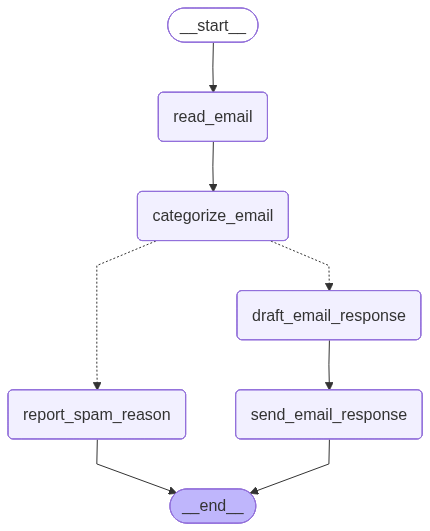

In [19]:
# creating the state graph for the email processing workflow
email_workflow = StateGraph(EmailState)

# adding nodes to the workflow
email_workflow.add_node("read_email", read_email)
email_workflow.add_node("categorize_email", categorize_email)
email_workflow.add_node("report_spam_reason", report_spam_reason)
email_workflow.add_node("draft_email_response", draft_email_response)
email_workflow.add_node("send_email_response", send_email_response)

# linear edges
email_workflow.add_edge(START, "read_email")
email_workflow.add_edge("read_email", "categorize_email")

# branch on the classification: route_email() returns the name of the next node
email_workflow.add_conditional_edges(
    "categorize_email",
    route_email,
    {
        "report_spam_reason": "report_spam_reason",
        "draft_email_response": "draft_email_response",
    },
)

email_workflow.add_edge("report_spam_reason", END)
email_workflow.add_edge("draft_email_response", "send_email_response")
email_workflow.add_edge("send_email_response", END)

# Compile the graph
compiled_graph = email_workflow.compile()

# Optional: visualize the workflow
try:
    from IPython.display import Image, display
    display(Image(compiled_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(compiled_graph.get_graph().draw_mermaid())

### Execute the Agent app

In [20]:
# --- Run the agent over recent unread inbox emails ---
messages = list_unread(max_results=5)
print(f"Found {len(messages)} unread email(s).\n")

callbacks = [langfuse_handler] if langfuse_handler else None
for ref in messages:
    email = get_email(ref["id"])

    initial_state: EmailState = {
        "email": email,
        "email_category": None,
        "spam_reason": None,
        "is_spam": None,
        "email_draft": None,
        "messages": [],
    }
    result = compiled_graph.invoke(
        initial_state,
        config={"callbacks": callbacks} if callbacks else None,
    )
    print("—" * 50)

Found 5 unread email(s).

📥 Reading email from PC Optimum <noreply@em.pcoptimum.ca> — 🚨 EXPIRING SOON: Activate and shop your weekly offers.
🏷️  category=notification  is_spam=False
✍️  Draft prepared.
📧 Draft created → noreply@em.pcoptimum.ca  (draft id: r-2436209386559987350)
——————————————————————————————————————————————————
📥 Reading email from The Coding Gopher <thecodinggopher@substack.com> — File, Block, and Object Storage Explained
🏷️  category=notification  is_spam=False
✍️  Draft prepared.
📧 Draft created → thecodinggopher@substack.com  (draft id: r4215305002931468740)
——————————————————————————————————————————————————
📥 Reading email from support@groq.com — Notice: Your Groq API Key will expire in 7 days
🏷️  category=notification  is_spam=False
✍️  Draft prepared.
📧 Draft created → support@groq.com  (draft id: r2805075377502708110)
——————————————————————————————————————————————————
📥 Reading email from Cassie from Devpost <cassie@devpost.com> — HACKATHONS just for you, Sakib

### Inspecting Our Mail Sorting Agent with Langfuse 📡

In [21]:
# Optional: trace every LLM + node run in Langfuse.
# Needs LANGFUSE_PUBLIC_KEY / LANGFUSE_SECRET_KEY (and LANGFUSE_HOST) in your .env.
from langfuse.langchain import CallbackHandler

os.environ.setdefault("LANGFUSE_HOST", os.environ.get("LANGFUSE_HOST", "https://cloud.langfuse.com"))

langfuse_handler = CallbackHandler()
print("✅ Langfuse tracing enabled — re-run the execution cell above to capture a trace.")

✅ Langfuse tracing enabled — re-run the execution cell above to capture a trace.
